In [1]:
from __future__ import print_function, division
import mdtraj as md
import os
import sys
import numpy as np
import scipy as sp

import matplotlib.pyplot as plt


import math
import itertools    
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
import json

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [2]:
data_dir = os.getcwd()

In [4]:
rg_400K = json.load(open(data_dir+'/rg_400.json'))
rg_500K = json.load(open(data_dir+'/rg_500.json'))
rg_kappa = json.load(open(data_dir+'/rg_kappa.json'))

/var/folders/n9/rm4y5ph90gn669rryfxg_bpw0000gn/T/ipykernel_29490/4118612341.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, len(keys))


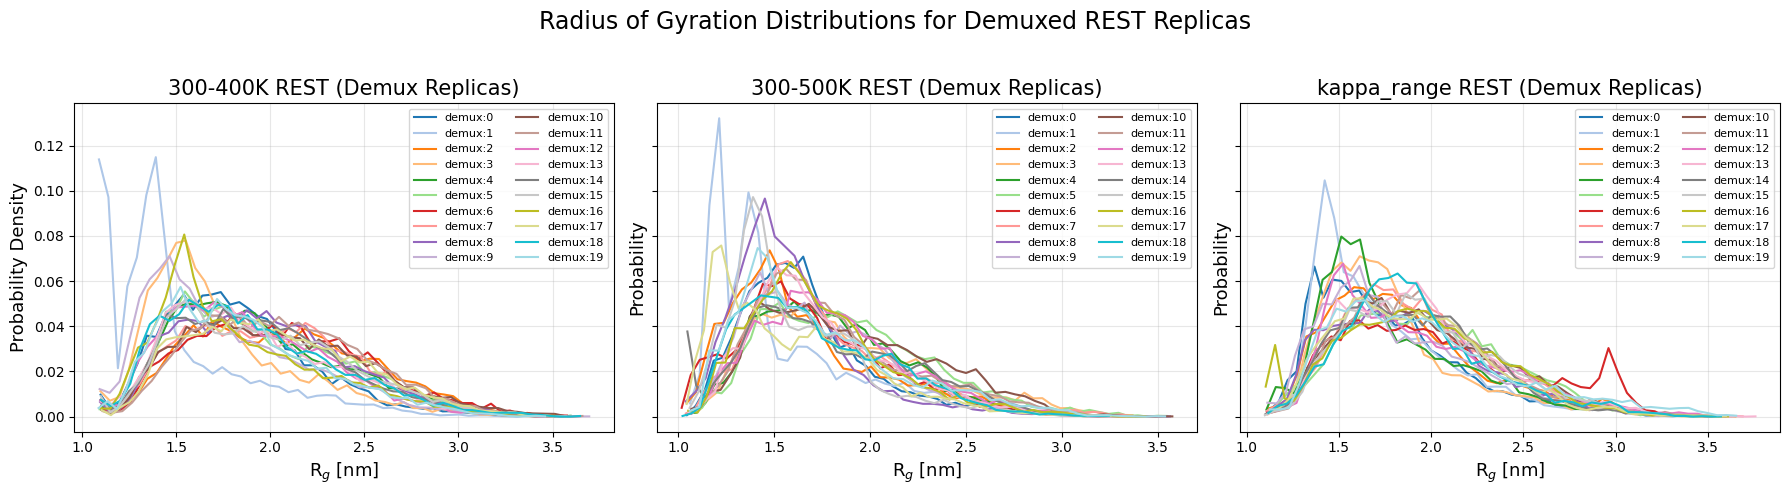

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- pmf1d function ---
def pmf1d(x, nbins, range=None, weights=None, return_bin_centers=True):
    count, edge = np.histogram(x, bins=nbins, range=range, weights=weights)
    if weights is None:
        p = count / len(x)
    else:
        p = count
    if return_bin_centers:
        return p, edge[:-1] + np.diff(edge) / 2
    else:
        return p

# --- Helper to plot Rg distributions ---
def plot_rg_demux_distributions(rg_dict, title, ax, nbins=50, cmap_name='tab20'):
    keys = [k for k in rg_dict if k.startswith('demux:')]
    keys.sort(key=lambda x: int(x.split(':')[1]))
    cmap = plt.cm.get_cmap(cmap_name, len(keys))
    colors = [cmap(i) for i in range(len(keys))]

    for i, key in enumerate(keys):
        x = np.array(rg_dict[key])
        p, bc = pmf1d(x, nbins=nbins)
        ax.plot(bc, p, color=colors[i], lw=1.5, label=f"{key}")

    ax.set_xlabel('R$_g$ [nm]', fontsize=13)
    ax.set_ylabel('Probability', fontsize=13)
    ax.set_title(title, fontsize=15)
    ax.legend(fontsize=8, ncols=2, loc='best', frameon=True)
    ax.grid(alpha=0.3)

# --- Input dictionaries ---
datasets = {
    '300-400K': rg_400K,
    '300-500K': rg_500K,
    'kappa_range': rg_kappa
}

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, rg_dict) in zip(axes, datasets.items()):
    plot_rg_demux_distributions(rg_dict, title=f"{name} REST (Demux Replicas)", ax=ax)

axes[0].set_ylabel('Probability Density', fontsize=13)
fig.suptitle('Radius of Gyration Distributions for Demuxed REST Replicas', fontsize=17)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


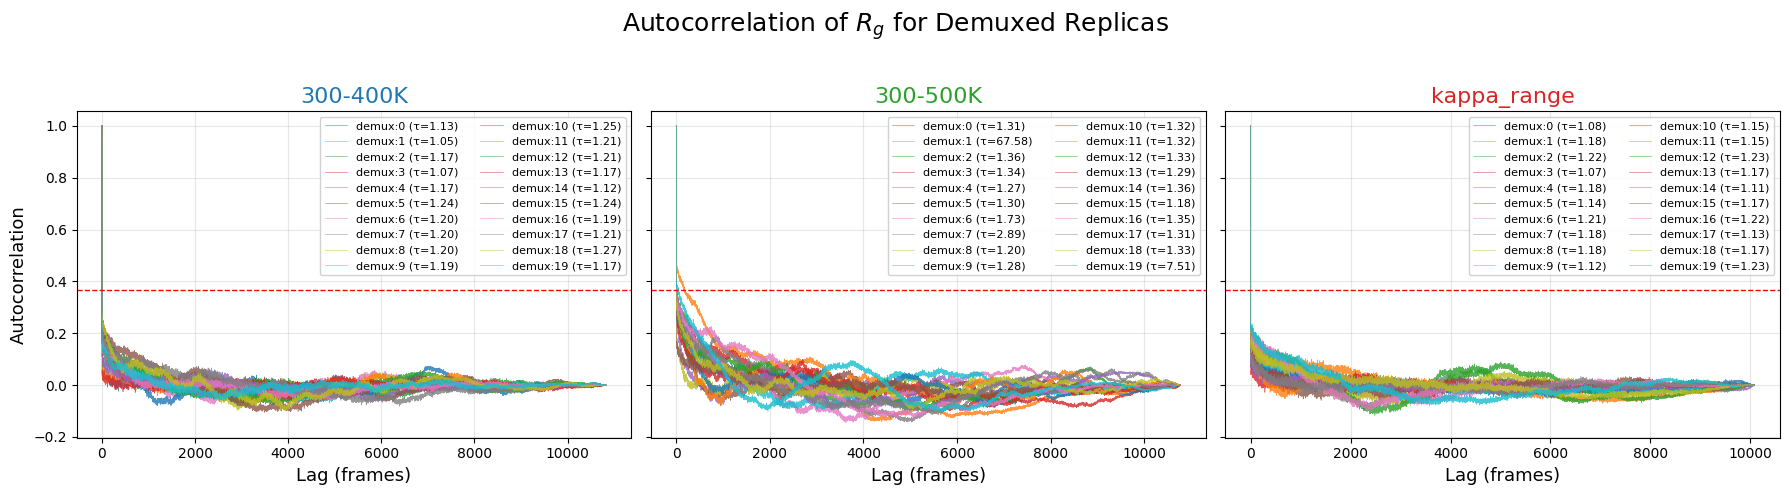

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import json

# --- Functions ---
def acf(x):
    """Compute normalized autocorrelation function using FFT."""
    N = len(x)
    x = x - np.mean(x)
    return np.fft.ifft(np.abs(np.fft.fft(x, n=2*N))**2).real[:N] / (N * np.var(x))

def get_time(acf_vals, cutoff=np.exp(-1)):
    """Integrate ACF up to first crossing below cutoff."""
    idx = np.argmax(acf_vals <= cutoff)
    return np.sum(acf_vals[:idx+1]) if idx > 0 else np.nan


# --- Datasets ---
datasets = {
    '300-400K': rg_400K,
    '300-500K': rg_500K,
    'kappa_range': rg_kappa
}

colors = {
    '300-400K': '#1f77b4',
    '300-500K': '#2ca02c',
    'kappa_range': '#d62728'
}


# --- (a) Subplots for ACFs with demux τ legends ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
taus_dict = {}

for ax, (label, rg_dict) in zip(axes, datasets.items()):
    taus = []
    n_demux = len([k for k in rg_dict if k.startswith('demux:')])
    
    for i in range(n_demux):
        key = f'demux:{i}'
        rg_vals = np.array(rg_dict[key])
        acf_vals = acf(rg_vals)
        tau = get_time(acf_vals)
        taus.append(tau)
        ax.plot(acf_vals, lw=0.4, alpha=0.8, label=f'{key} (τ={tau:.2f})')
    
    taus_dict[label] = np.array(taus)
    
    ax.axhline(np.exp(-1), color='red', ls='--', lw=1)
    ax.set_title(f"{label}", fontsize=16, color=colors[label])
    ax.set_xlabel("Lag (frames)", fontsize=13)
    ax.grid(alpha=0.3)
    
    # Legend inside subplot (adjust loc if it overlaps)
    ax.legend(fontsize=8, loc='upper right', ncol=2, frameon=True, framealpha=0.9)

axes[0].set_ylabel("Autocorrelation", fontsize=13)
fig.suptitle("Autocorrelation of $R_g$ for Demuxed Replicas", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



In [15]:
from writhe_tools.utils import lsdir, reindex_list
from writhe_tools.md_tools import ResidueDistances
import mdtraj as md

In [18]:
dir_400k = '/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/apo_400K/xtc_files/d/'
dir_500k = '/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/apo_500K/xtc_files/d/'
dir_kappas = '/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/apo_kappa_diff/xtc_files/d/'

pdb_400k = '/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/apo_400k/xtc_files/prot_ions.pdb'
pdb_500k = '/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/apo_500k/xtc_files/prot_ions.pdb'
pdb_kappas = '/Users/kaushikborthakur1211/Desktop/p27/New_2025_runs/kappa_tests/apo_kappa_diff/xtc_files/prot_ions.pdb'

In [13]:
from writhe_tools.stats import pca
from writhe_tools.writhe import Writhe

[writhe_tools] ⏭️ Skipping 'graph_utils' (missing: torch_geometric)
[writhe_tools] 👉 To enable this module, install: pip install writhe-tools[graph]


2025-10-21 14:11:08,164	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [16]:
files = lsdir(dir_400k, keyword = ['xtc'], match=all)
top = md.load(pdb_400k).top
coords = [md.load(file, top=pdb_400k, atom_indices=top.select('name CA')).xyz for file in files]
lengths = np.fromiter(map(len, coords), int)
writhe = Writhe(np.concatenate(coords))
writhe.compute_writhe(length=5)
writhe.save('./writhe_400k')

2025-10-21 14:13:32,711	INFO worker.py:1951 -- Started a local Ray instance.


In [19]:
files = lsdir(dir_500k, keyword = ['xtc'], match=all)
top = md.load(pdb_500k).top
coords = [md.load(file, top=pdb_500k, atom_indices=top.select('name CA')).xyz for file in files]
lengths = np.fromiter(map(len, coords), int)
writhe = Writhe(np.concatenate(coords))
writhe.compute_writhe(length=5)
writhe.save('./writhe_500k')

2025-10-21 14:17:48,690	INFO worker.py:1951 -- Started a local Ray instance.


In [20]:
files = lsdir(dir_kappas, keyword = ['xtc'], match=all)
top = md.load(pdb_kappas).top
coords = [md.load(file, top=pdb_kappas, atom_indices=top.select('name CA')).xyz for file in files]
lengths = np.fromiter(map(len, coords), int)
writhe = Writhe(np.concatenate(coords))
writhe.compute_writhe(length=5)
writhe.save('./writhe_kappas')

2025-10-21 14:19:51,952	INFO worker.py:1951 -- Started a local Ray instance.


In [21]:
writhe_400k = Writhe.load('writhe_400k/writhe_data_dict_length_5.pkl')
writhe_500k = Writhe.load('writhe_500k/writhe_data_dict_length_5.pkl')
writhe_kappas = Writhe.load('writhe_kappas/writhe_data_dict_length_5.pkl')

In [24]:
writhe_kappas.writhe_features.shape

(201700, 865)

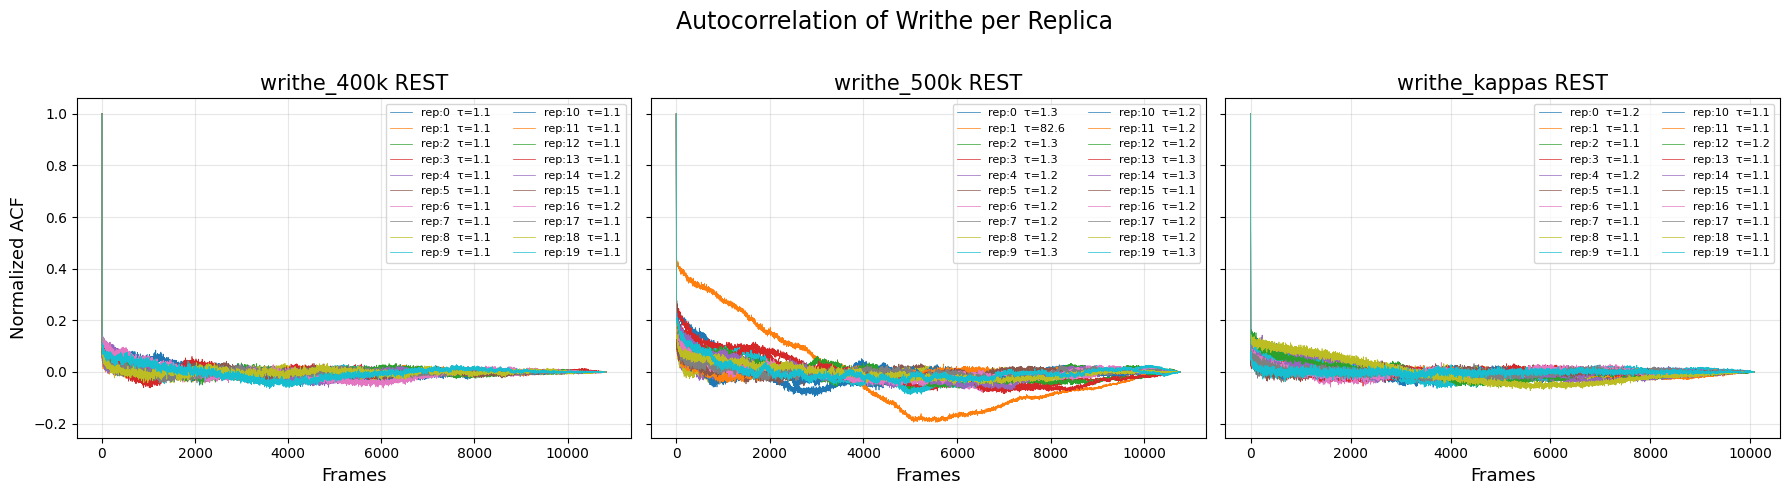

In [26]:
import numpy as np
import matplotlib.pyplot as plt


datasets = {
    "writhe_400k": writhe_400k.writhe_features,
    "writhe_500k": writhe_500k.writhe_features,
    "writhe_kappas": writhe_kappas.writhe_features
}

nrep = 20
nframes_dict = {
    "writhe_400k": 216540//nrep,
    "writhe_500k": 215420 // nrep,
    "writhe_kappas": 201700// nrep
}

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, arr) in zip(axes, datasets.items()):
    nframes = nframes_dict[name]
    taus = []

    for i in range(nrep):
        start = i * nframes
        end = (i + 1) * nframes
        data = np.mean(arr[start:end, :], axis=1)

        acf_vals = acf(data)
        tau = get_time(acf_vals)
        taus.append(tau)

        ax.plot(acf_vals, lw=0.5, label=f"rep:{i}  τ={tau:.1f}")

    ax.set_title(f"{name} REST", fontsize=15)
    ax.set_xlabel("Frames", fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best", frameon=True, ncols=2)

axes[0].set_ylabel("Normalized ACF", fontsize=13)
fig.suptitle("Autocorrelation of Writhe per Replica", fontsize=17)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


/var/folders/n9/rm4y5ph90gn669rryfxg_bpw0000gn/T/ipykernel_29490/216313577.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, nrep)


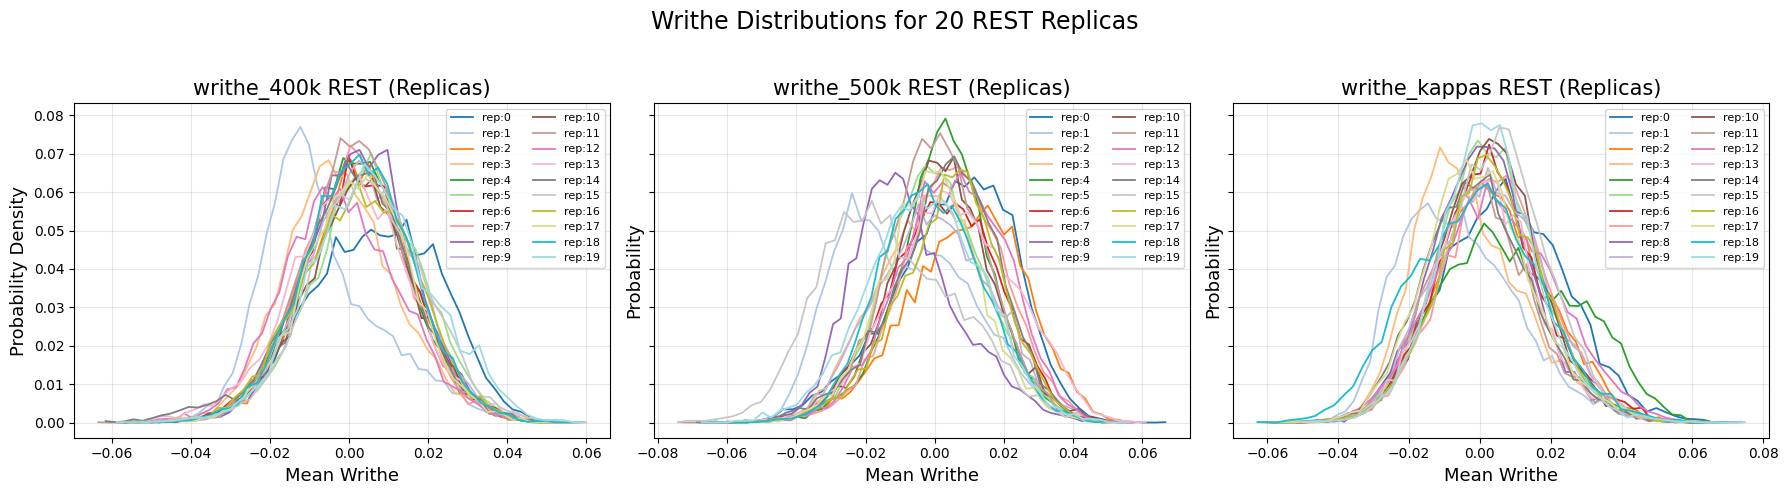

In [27]:

def plot_writhe_distributions(writhe_arr, nrep, title, ax, nbins=50, cmap_name='tab20'):
    nframes = writhe_arr.shape[0] // nrep
    cmap = plt.cm.get_cmap(cmap_name, nrep)
    colors = [cmap(i) for i in range(nrep)]

    for i in range(nrep):
        start = i * nframes
        end = (i + 1) * nframes
        # average across features per frame
        x = np.mean(writhe_arr[start:end, :], axis=1)
        p, bc = pmf1d(x, nbins=nbins)
        ax.plot(bc, p, color=colors[i], lw=1.3, label=f"rep:{i}")

    ax.set_xlabel('Mean Writhe', fontsize=13)
    ax.set_ylabel('Probability', fontsize=13)
    ax.set_title(title, fontsize=15)
    ax.legend(fontsize=8, ncols=2, loc='best', frameon=True)
    ax.grid(alpha=0.3)

datasets = {
    "writhe_400k": writhe_400k.writhe_features,
    "writhe_500k": writhe_500k.writhe_features,
    "writhe_kappas": writhe_kappas.writhe_features
}

nrep = 20
nframes_dict = {
    "writhe_400k": 216540//nrep,
    "writhe_500k": 215420 // nrep,
    "writhe_kappas": 201700// nrep
}


# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (name, arr) in zip(axes, datasets.items()):
    plot_writhe_distributions(arr, nrep, title=f"{name} REST (Replicas)", ax=ax)

axes[0].set_ylabel('Probability Density', fontsize=13)
fig.suptitle('Writhe Distributions for 20 REST Replicas', fontsize=17)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
